In [15]:
import pandas as pd
import numpy as np
import os
import re
from sqlalchemy import create_engine, inspect, text
from IPython.display import Image, display

In [ ]:
# Ruta donde están los archivos CSV
FOLDER_PATH = r'C:\Users\Asus\Documents\IT\Especialidad_IT_Academy\Proyecto\ddbb'

# Lista de provincias que renovaron diputados en 2025
# PROVINCIAS_RENOVACION_2025 = [
#     'buenos aires', 'catamarca', 'chaco', 'chubut', 'corrientes', 'entre rios',
#     'formosa', 'jujuy', 'la pampa', 'la rioja', 'mendoza', 'misiones', 'neuquen',
#     'rio negro', 'salta', 'san juan', 'san luis', 'santa cruz', 'santa fe',
#     'santiago del estero', 'tierra del fuego'
# ]

# Lista oficial de las 24 jurisdicciones (id_normalizado, nombre_completo)
JURISDICCIONES_OFICIALES = [
    ('buenos aires', 'buenos aires'),
    ('caba', 'ciudad autónoma de buenos aires'),
    ('catamarca', 'catamarca'),
    ('chaco', 'chaco'),
    ('chubut', 'chubut'),
    ('córdoba', 'córdoba'),
    ('corrientes', 'corrientes'),
    ('entre ríos', 'entre ríos'),
    ('formosa', 'formosa'),
    ('jujuy', 'jujuy'),
    ('la pampa', 'la pampa'),
    ('la rioja', 'la rioja'),
    ('mendoza', 'mendoza'),
    ('misiones', 'misiones'),
    ('neuquén', 'neuquén'),
    ('río negro', 'río negro'),
    ('salta', 'salta'),
    ('san juan', 'san juan'),
    ('san luis', 'san luis'),
    ('santa cruz', 'santa cruz'),
    ('santa fe', 'santa fe'),
    ('santiago del estero', 'santiago del estero'),
    ('tierra del fuego', 'tierra del fuego'),
    ('tucumán', 'tucumán')
]

# Personas trans identificadas manualmente
PERSONAS_TRANS_RAW = {
    ('ibañez', 'reina xiomara'),
    ('antunez', 'julieta'),
    ('infante', 'ornela reina')
}

# Clasificación ideológica de partidos (1=progresista, 5=conservador)
CLASIFICACION_PARTIDOS = {
    'frente de izquierda': {'espacio': 'FIT', 'eje': 1},
    'partido obrero': {'espacio': 'FIT', 'eje': 1},
    'mst': {'espacio': 'FIT', 'eje': 1},
    'izquierda': {'espacio': 'FIT', 'eje': 1},
    'union por la patria': {'espacio': 'UP', 'eje': 2},
    'frente de todos': {'espacio': 'UP', 'eje': 2},
    'partido justicialista': {'espacio': 'UP', 'eje': 2},
    'justicialista': {'espacio': 'UP', 'eje': 2},
    'coalicion civica': {'espacio': 'Centro', 'eje': 3},
    'partido socialista': {'espacio': 'Centro', 'eje': 3},
    'gen': {'espacio': 'Centro', 'eje': 3},
    'juntos por el cambio': {'espacio': 'JxC', 'eje': 4},
    'pro': {'espacio': 'JxC', 'eje': 4},
    'union civica radical': {'espacio': 'JxC', 'eje': 4},
    'ucr': {'espacio': 'JxC', 'eje': 4},
    'la libertad avanza': {'espacio': 'LLA', 'eje': 5},
    'partido democrata': {'espacio': 'LLA', 'eje': 5},
    'libertad avanza': {'espacio': 'LLA', 'eje': 5},
}

# Unificación de nombres de partidos (evita duplicados)
UNIFICAR_PARTIDOS = {
    'pro': 'propuesta republicana',
    'ucr': 'union civica radical',
    'cambiemos': 'juntos por el cambio',
    'frente de todos': 'union por la patria',
    'libertad avanza': 'la libertad avanza',
}

# Unificación de nombres de personas (casos detectados manualmente)
UNIFICAR_PERSONAS = {
    ('fernandez', 'elia marina'): ('fernandez de mansilla', 'elia'),
    ('brugge', 'eliana'): ('bruno', 'eliana'),
    ('ali', 'ernesto pipi'): ('ali', 'ernesto'),
}

In [3]:
# Definición de funciones auxiliares

def normalizar_texto(texto):
    """Convierte texto a minúsculas, sin tildes ni caracteres especiales."""
    if not texto or pd.isna(texto):
        return None
    texto = str(texto).lower().strip()
    texto = texto.replace('á', 'a').replace('é', 'e').replace('í', 'i')
    texto = texto.replace('ó', 'o').replace('ú', 'u').replace('ñ', 'n')
    texto = re.sub(r'[^a-z0-9_\-\s]', '', texto)
    return texto


def normalizar_genero(genero):
    """Clasifica el género en categorías estandarizadas."""
    if not genero or pd.isna(genero):
        return 'no_reporte'
    g = str(genero).lower().strip()
    if g in ['femenino', 'mujer', 'f', 'female']:
        return 'femenino'
    if g in ['masculino', 'varon', 'hombre', 'm', 'male']:
        return 'masculino'
    if g in ['no binario', 'no binarie', 'nb']:
        return 'no_binario'
    if g in ['n', 's/d', 'sin datos']:
        return 'no_reporte'
    return 'no_reporte'


def normalizar_jurisdiccion(nombre):
    """Estandariza nombres de provincias y CABA."""
    if not nombre:
        return None
    nombre = normalizar_texto(nombre)
    if not nombre:
        return None
    # Mapeo de variantes comunes
    if nombre in ['caba', 'ciudad autonoma de buenos aires']:
        return 'caba'
    if nombre in ['cordoba', 'cba']:
        return 'córdoba'
    if nombre == 'tucuman':
        return 'tucumán'
    if nombre == 'neuquen':
        return 'neuquén'
    if nombre in ['rionegro', 'rio negro']:
        return 'río negro'
    if nombre in ['entrerios', 'entre rios']:
        return 'entre ríos'
    return nombre


def identificar_personas_trans():
    """Normaliza los nombres de las personas trans para su identificación."""
    personas_trans = set()
    for apellido, nombre in PERSONAS_TRANS_RAW:
        ap_clean = normalizar_texto(apellido)
        nom_clean = normalizar_texto(nombre)
        if ap_clean and nom_clean:
            personas_trans.add((ap_clean, nom_clean))
    return personas_trans

In [4]:
# Conectar base de datos SQLite

engine = create_engine('sqlite:///modelo_limpio.db', echo=False)
print("Base de datos 'modelo_limpio.db' lista")

Base de datos 'modelo_limpio.db' lista


In [5]:
# Cargar todos los CSVs en un diccionario

print("Cargando archivos CSV...")

csv_files = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.csv')]
print(f"Archivos encontrados: {len(csv_files)}")

dataframes = {}

for i, file in enumerate(csv_files):
    file_path = os.path.join(FOLDER_PATH, file)
    df_name = os.path.splitext(file)[0]
    try:
        dataframes[df_name] = pd.read_csv(file_path)
        if (i + 1) % 50 == 0:
            print(f"Progreso: {i+1}/{len(csv_files)}")
    except Exception as e:
        print(f"Error cargando {file}: {e}")

print(f"Se cargaron {len(dataframes)} DataFrames")

Cargando archivos CSV...
Archivos encontrados: 283
Progreso: 50/283
Progreso: 100/283
Progreso: 150/283
Progreso: 200/283
Progreso: 250/283
Se cargaron 283 DataFrames


In [6]:
# Crear tabla 'jurisdiccion'

jurisdiccion_data = []

for id_norm, nombre_completo in JURISDICCIONES_OFICIALES:
    id_clean = id_norm.replace(' ', '_').replace('í', 'i').replace('é', 'e')
    jurisdiccion_data.append({
        'id_jurisdiccion': f"JUR_{id_clean}",
        'nombre': id_norm,
        'nombre_completo': nombre_completo,
        'region': None,
        'ley_paridad': None,
        'anio_ley_paridad': None,
        'diseño_electoral': None
    })

jurisdiccion_df = pd.DataFrame(jurisdiccion_data)
jurisdiccion_df.to_sql('jurisdiccion', engine, if_exists='replace', index=False)
print(f"Tabla 'jurisdiccion' creada: {len(jurisdiccion_df)} registros")

Tabla 'jurisdiccion' creada: 24 registros


In [7]:
# Crear tabla 'periodo' (composición y mandato)

periodo_data = []

# Períodos de composición (cámara)
composiciones = [
    ('2019-2021', 2019, 2021),
    ('2021-2023', 2021, 2023),
    ('2023-2025', 2023, 2025),
    ('2025-2027', 2025, 2027),
]

for composicion, inicio, fin in composiciones:
    periodo_data.append({
        'id_periodo': f"PER_{composicion}",
        'composicion': composicion,
        'mandato': None,
        'anio_inicio': inicio,
        'anio_fin': fin
    })

# Períodos de mandato individual (para renovaciones)
mandatos = [
    ('2019-2023', 2019, 2023),
    ('2021-2025', 2021, 2025),
    ('2023-2027', 2023, 2027),
    ('2025-2029', 2025, 2029),
]

for mandato, inicio, fin in mandatos:
    periodo_data.append({
        'id_periodo': f"PER_MAND_{mandato}",
        'composicion': None,
        'mandato': mandato,
        'anio_inicio': inicio,
        'anio_fin': fin
    })

periodo_df = pd.DataFrame(periodo_data)
periodo_df.to_sql('periodo', engine, if_exists='replace', index=False)
print(f"Tabla 'periodo' creada: {len(periodo_df)} registros")

Tabla 'periodo' creada: 8 registros


In [8]:
# Crear tabla 'partido' (con eje ideológico)

partido_data = {}
columnas_partido = ['bloque', 'partido_o_alianza', 'alianza', 'espacio_politico']

for nombre_archivo, df in dataframes.items():
    for col in columnas_partido:
        if col in df.columns:
            for valor in df[col].dropna().unique():
                nombre_limpio = normalizar_texto(valor)
                if not nombre_limpio:
                    continue
                
                # Unificar variantes del mismo partido
                nombre_base = UNIFICAR_PARTIDOS.get(nombre_limpio, nombre_limpio)
                
                if nombre_base not in partido_data:
                    # Clasificación ideológica
                    clasificacion = None
                    for key, value in CLASIFICACION_PARTIDOS.items():
                        if key in nombre_base or nombre_base in key:
                            clasificacion = value
                            break
                    
                    if not clasificacion:
                        clasificacion = {'espacio': 'Provincial', 'eje': 3}
                    
                    partido_data[nombre_base] = {
                        'id_partido': f"PAR_{nombre_base.replace(' ', '_')[:50]}",
                        'nombre': nombre_base,
                        'espacio_nacional': clasificacion['espacio'],
                        'eje_ideologico': clasificacion['eje']
                    }

partido_df = pd.DataFrame(list(partido_data.values()))
partido_df.to_sql('partido', engine, if_exists='replace', index=False)
print(f"Tabla 'partido' creada: {len(partido_df)} registros")

Tabla 'partido' creada: 624 registros


In [9]:
# Crear tabla 'persona' (con género y personas trans)

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS persona"))
    conn.commit()

PERSONAS_TRANS = identificar_personas_trans()
print(f"Personas trans a identificar: {PERSONAS_TRANS}")

persona_data = {}
personas_vistas = set()

for nombre_archivo, df in dataframes.items():
    if 'apellido' in df.columns and 'nombre' in df.columns:
        for idx, row in df.iterrows():
            apellido_raw = str(row['apellido']) if pd.notna(row['apellido']) else None
            nombre_raw = str(row['nombre']) if pd.notna(row['nombre']) else None
            
            if not apellido_raw or not nombre_raw:
                continue
            
            apellido_clean = normalizar_texto(apellido_raw)
            nombre_clean = normalizar_texto(nombre_raw)
            
            if not apellido_clean or not nombre_clean:
                continue
            
            # Unificar duplicados detectados manualmente
            clave_original = (apellido_clean, nombre_clean)
            if clave_original in UNIFICAR_PERSONAS:
                apellido_clean, nombre_clean = UNIFICAR_PERSONAS[clave_original]
            
            clave = f"{apellido_clean}|{nombre_clean}"
            if clave not in personas_vistas:
                personas_vistas.add(clave)
                
                genero_raw = None
                if 'genero' in df.columns and pd.notna(row['genero']):
                    genero_raw = str(row['genero'])
                genero_normalizado = normalizar_genero(genero_raw)
                
                es_trans = 1 if (apellido_clean, nombre_clean) in PERSONAS_TRANS else 0
                
                if es_trans:
                    print(f"Trans identificada: {apellido_raw}, {nombre_raw}")
                
                persona_data[clave] = {
                    'id_persona': f"PER_{apellido_clean}_{nombre_clean[:30]}",
                    'apellido': apellido_raw.lower().strip(),
                    'nombre': nombre_raw.lower().strip(),
                    'genero': genero_normalizado,
                    'es_trans': es_trans
                }

persona_df = pd.DataFrame(list(persona_data.values()))
persona_df.to_sql('persona', engine, if_exists='replace', index=False)
print(f"Tabla 'persona' creada: {len(persona_df)} registros")
print(f"Personas trans identificadas: {persona_df['es_trans'].sum()}")

Personas trans a identificar: {('ibanez', 'reina xiomara'), ('antunez', 'julieta'), ('infante', 'ornela reina')}
Trans identificada: Antúnez, Julieta
Trans identificada: Infante, Ornela Reina
Tabla 'persona' creada: 8159 registros
Personas trans identificadas: 2


In [10]:
# Crear tabla 'banca' (relación persona-cargo)

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS banca"))
    conn.commit()

banca_data = []
bancas_vistas = set()

for nombre_archivo, df in dataframes.items():
    # Solo procesar archivos con legisladores
    if not any(x in nombre_archivo for x in ['HCDN', 'HSN', 'HCD', 'HS']):
        continue
    if 'apellido' not in df.columns or 'nombre' not in df.columns:
        continue
    
    # Determinar cámara y nivel según el nombre del archivo
    if 'HCDN' in nombre_archivo:
        camara, nivel = 'diputados', 'nacional'
    elif 'HSN' in nombre_archivo:
        camara, nivel = 'senadores', 'nacional'
    elif 'HCD' in nombre_archivo:
        camara, nivel = 'diputados', 'provincial'
    elif 'HS' in nombre_archivo:
        camara, nivel = 'senadores', 'provincial'
    else:
        continue
    
    for idx, row in df.iterrows():
        apellido_raw = str(row['apellido']) if pd.notna(row['apellido']) else None
        nombre_raw = str(row['nombre']) if pd.notna(row['nombre']) else None
        
        if not apellido_raw or not nombre_raw:
            continue
        
        apellido_clean = normalizar_texto(apellido_raw)
        nombre_clean = normalizar_texto(nombre_raw)
        
        if not apellido_clean or not nombre_clean:
            continue
        
        id_persona = f"PER_{apellido_clean}_{nombre_clean[:30]}"
        
        # Obtener período de composición
        if 'composicion' in df.columns and pd.notna(row['composicion']):
            id_periodo = f"PER_{row['composicion']}"
        else:
            continue
        
        # Obtener jurisdicción
        jurisdiccion_nombre = None
        for col_jur in ['provincia', 'jurisdicción', 'jurisdiccion', 'distrito', 'seccion']:
            if col_jur in df.columns and pd.notna(row[col_jur]):
                jurisdiccion_nombre = normalizar_jurisdiccion(row[col_jur])
                break
        
        if not jurisdiccion_nombre and nivel == 'nacional' and 'distrito' in df.columns:
            jurisdiccion_nombre = normalizar_jurisdiccion(row['distrito'])
        
        if not jurisdiccion_nombre:
            continue
        
        id_clean = jurisdiccion_nombre.replace(' ', '_').replace('í', 'i').replace('é', 'e')
        id_jurisdiccion = f"JUR_{id_clean}"
        
        # Obtener partido
        partido_nombre = None
        for col_par in ['bloque', 'partido_o_alianza', 'alianza']:
            if col_par in df.columns and pd.notna(row[col_par]):
                partido_nombre = normalizar_texto(row[col_par])
                break
        
        if partido_nombre:
            if partido_nombre in ['pro', 'propuesta republicana']:
                partido_nombre = 'propuesta republicana'
            elif partido_nombre in ['ucr', 'union civica radical']:
                partido_nombre = 'union civica radical'
            elif partido_nombre in ['frente de todos', 'union por la patria']:
                partido_nombre = 'union por la patria'
            elif partido_nombre in ['libertad avanza', 'la libertad avanza']:
                partido_nombre = 'la libertad avanza'
        
        id_partido = f"PAR_{partido_nombre.replace(' ', '_')[:50]}" if partido_nombre else None
        
        # Determinar si es cabeza de lista (orden = 1)
        es_cabeza_lista = 0
        if 'orden' in df.columns and pd.notna(row['orden']):
            try:
                es_cabeza_lista = 1 if int(float(row['orden'])) == 1 else 0
            except:
                pass
        
        # Años de vigencia del mandato
        anios = row['composicion'].split('-')
        anio_asuncion = int(anios[0]) if len(anios) >= 1 else None
        anio_vencimiento = int(anios[1]) if len(anios) >= 2 else None
        
        clave_banca = f"{id_persona}|{id_periodo}|{camara}|{id_jurisdiccion}"
        if clave_banca not in bancas_vistas:
            bancas_vistas.add(clave_banca)
            banca_data.append({
                'id_banca': f"BNC_{apellido_clean}_{nombre_clean[:10]}_{camara[:3]}"[:100],
                'id_persona': id_persona,
                'id_periodo': id_periodo,
                'id_jurisdiccion': id_jurisdiccion,
                'id_partido': id_partido,
                'camara': camara,
                'nivel': nivel,
                'es_cabeza_lista': es_cabeza_lista,
                'anio_asuncion': anio_asuncion,
                'anio_vencimiento': anio_vencimiento
            })

banca_df = pd.DataFrame(banca_data)
banca_df.to_sql('banca', engine, if_exists='replace', index=False)
print(f"Tabla 'banca' creada: {len(banca_df)} registros")

Tabla 'banca' creada: 2301 registros


In [24]:
# ============================================================
# VERIFICACIÓN Y COMPLETADO DE BANCAS FALTANTES
# ============================================================

# Definir los totales esperados por cámara a nivel nacional
TOTALES_ESPERADOS = {
    'diputados': 257,
    'senadores': 72
}

# Períodos a verificar (puedes ajustar según necesites)
PERIODOS_A_VERIFICAR = ['2019-2021', '2021-2023', '2023-2025', '2025-2027']

# Función para crear persona "no informado" si no existe
def crear_persona_not_informed(camara, periodo):
    id_persona = f"PER_not_informed_{camara}_{periodo.replace('-', '_')}"
    
    existe = pd.read_sql(
        f"SELECT * FROM persona WHERE id_persona = '{id_persona}'", 
        engine
    )
    
    if existe.empty:
        pd.DataFrame([{
            'id_persona': id_persona,
            'apellido': 'no informado',
            'nombre': f'{camara} {periodo}',
            'genero': 'no_reporte',
            'es_trans': 0
        }]).to_sql('persona', engine, if_exists='append', index=False)
        print(f"Creada persona 'no informado' para {camara} - {periodo}")
    
    return id_persona

# Función para obtener ID de período
def obtener_id_periodo(periodo_str):
    resultado = pd.read_sql(
        f"SELECT id_periodo FROM periodo WHERE composicion = '{periodo_str}'", 
        engine
    )
    if resultado.empty:
        return None
    return resultado.iloc[0]['id_periodo']

# Verificar y completar cada período y cámara
print("\n" + "="*60)
print("VERIFICACIÓN DE BANCAS POR PERÍODO Y CÁMARA")
print("="*60)

for periodo_str in PERIODOS_A_VERIFICAR:
    id_periodo = obtener_id_periodo(periodo_str)
    if id_periodo is None:
        print(f"⚠️ Período {periodo_str} no encontrado en tabla periodo")
        continue
    
    for camara in ['diputados', 'senadores']:
        total_actual = pd.read_sql(f"""
            SELECT COUNT(*) as total
            FROM banca b
            WHERE b.id_periodo = '{id_periodo}'
              AND b.camara = '{camara}'
              AND b.nivel = 'nacional'
        """, engine).iloc[0,0]
        
        total_esperado = TOTALES_ESPERADOS[camara]
        faltantes = total_esperado - total_actual
        
        print(f"{periodo_str} - {camara}: {total_actual}/{total_esperado} bancas", end="")
        
        if faltantes > 0:
            print(f" (faltan {faltantes})")
            
            # Crear persona "no informado" para esta cámara y período
            id_persona = crear_persona_not_informed(camara, periodo_str)
            
            # Obtener jurisdicciones para distribuir las bancas faltantes
            # (opcional: puedes asignarlas a una jurisdicción genérica)
            jurisdicciones = pd.read_sql(
                "SELECT id_jurisdiccion, nombre FROM jurisdiccion", 
                engine
            )
            
            # Agregar bancas faltantes (como "no informado" sin jurisdicción específica)
            for i in range(faltantes):
                # Usar primera jurisdicción como placeholder o NULL
                # En este caso, usamos la primera jurisdicción (podría ser 'caba')
                id_jur = jurisdicciones.iloc[0]['id_jurisdiccion']
                
                banca_data = {
                    'id_banca': f'BNC_not_informed_{camara}_{periodo_str.replace("-", "_")}_{i}',
                    'id_persona': id_persona,
                    'id_periodo': id_periodo,
                    'id_jurisdiccion': id_jur,
                    'id_partido': None,
                    'camara': camara,
                    'nivel': 'nacional',
                    'es_cabeza_lista': 0,
                    'anio_asuncion': int(periodo_str.split('-')[0]),
                    'anio_vencimiento': int(periodo_str.split('-')[1])
                }
                
                pd.DataFrame([banca_data]).to_sql('banca', engine, if_exists='append', index=False)
            
            print(f"  ✅ Se agregaron {faltantes} bancas 'no informado' para {camara} - {periodo_str}")
        
        else:
            print(" ✓")

# Verificación final después de completar
print("\n" + "="*60)
print("VERIFICACIÓN FINAL DE BANCAS")
print("="*60)

for periodo_str in PERIODOS_A_VERIFICAR:
    id_periodo = obtener_id_periodo(periodo_str)
    if id_periodo is None:
        continue
    
    for camara in ['diputados', 'senadores']:
        total = pd.read_sql(f"""
            SELECT COUNT(*) as total
            FROM banca b
            WHERE b.id_periodo = '{id_periodo}'
              AND b.camara = '{camara}'
              AND b.nivel = 'nacional'
        """, engine).iloc[0,0]
        
        print(f"{periodo_str} - {camara}: {total} bancas")
    
    print("-" * 30)

print("\n✅ Modelo relacional completo y verificado")


VERIFICACIÓN DE BANCAS POR PERÍODO Y CÁMARA
2019-2021 - diputados: 257/257 bancas ✓
2019-2021 - senadores: 72/72 bancas ✓
2021-2023 - diputados: 257/257 bancas ✓
2021-2023 - senadores: 72/72 bancas ✓
2023-2025 - diputados: 269/257 bancas ✓
2023-2025 - senadores: 72/72 bancas ✓
2025-2027 - diputados: 127/257 bancas (faltan 130)
Creada persona 'no informado' para diputados - 2025-2027
  ✅ Se agregaron 130 bancas 'no informado' para diputados - 2025-2027
2025-2027 - senadores: 72/72 bancas ✓

VERIFICACIÓN FINAL DE BANCAS
2019-2021 - diputados: 257 bancas
2019-2021 - senadores: 72 bancas
------------------------------
2021-2023 - diputados: 257 bancas
2021-2023 - senadores: 72 bancas
------------------------------
2023-2025 - diputados: 269 bancas
2023-2025 - senadores: 72 bancas
------------------------------
2025-2027 - diputados: 257 bancas
2025-2027 - senadores: 72 bancas
------------------------------

✅ Modelo relacional completo y verificado


In [25]:
# Verificación de BANCAS POR PERÍODO

print("\n" + "="*60)
print("VERIFICACIÓN DE BANCAS POR PERÍODO")
print("="*60)

for periodo in periodo_df['composicion'].dropna().unique():
    for camara in ['diputados', 'senadores']:
        total = pd.read_sql(f"""
            SELECT COUNT(*) as total
            FROM banca b
            JOIN periodo p ON b.id_periodo = p.id_periodo
            WHERE p.composicion = '{periodo}'
              AND b.camara = '{camara}'
              AND b.nivel = 'nacional'
        """, engine).iloc[0,0]
        if total > 0:
            print(f"{periodo} - {camara}: {total} bancas")

print("\nModelo relacional listo para análisis")


VERIFICACIÓN DE BANCAS POR PERÍODO
2019-2021 - diputados: 257 bancas
2019-2021 - senadores: 72 bancas
2021-2023 - diputados: 257 bancas
2021-2023 - senadores: 72 bancas
2023-2025 - diputados: 269 bancas
2023-2025 - senadores: 72 bancas
2025-2027 - diputados: 257 bancas
2025-2027 - senadores: 72 bancas

Modelo relacional listo para análisis


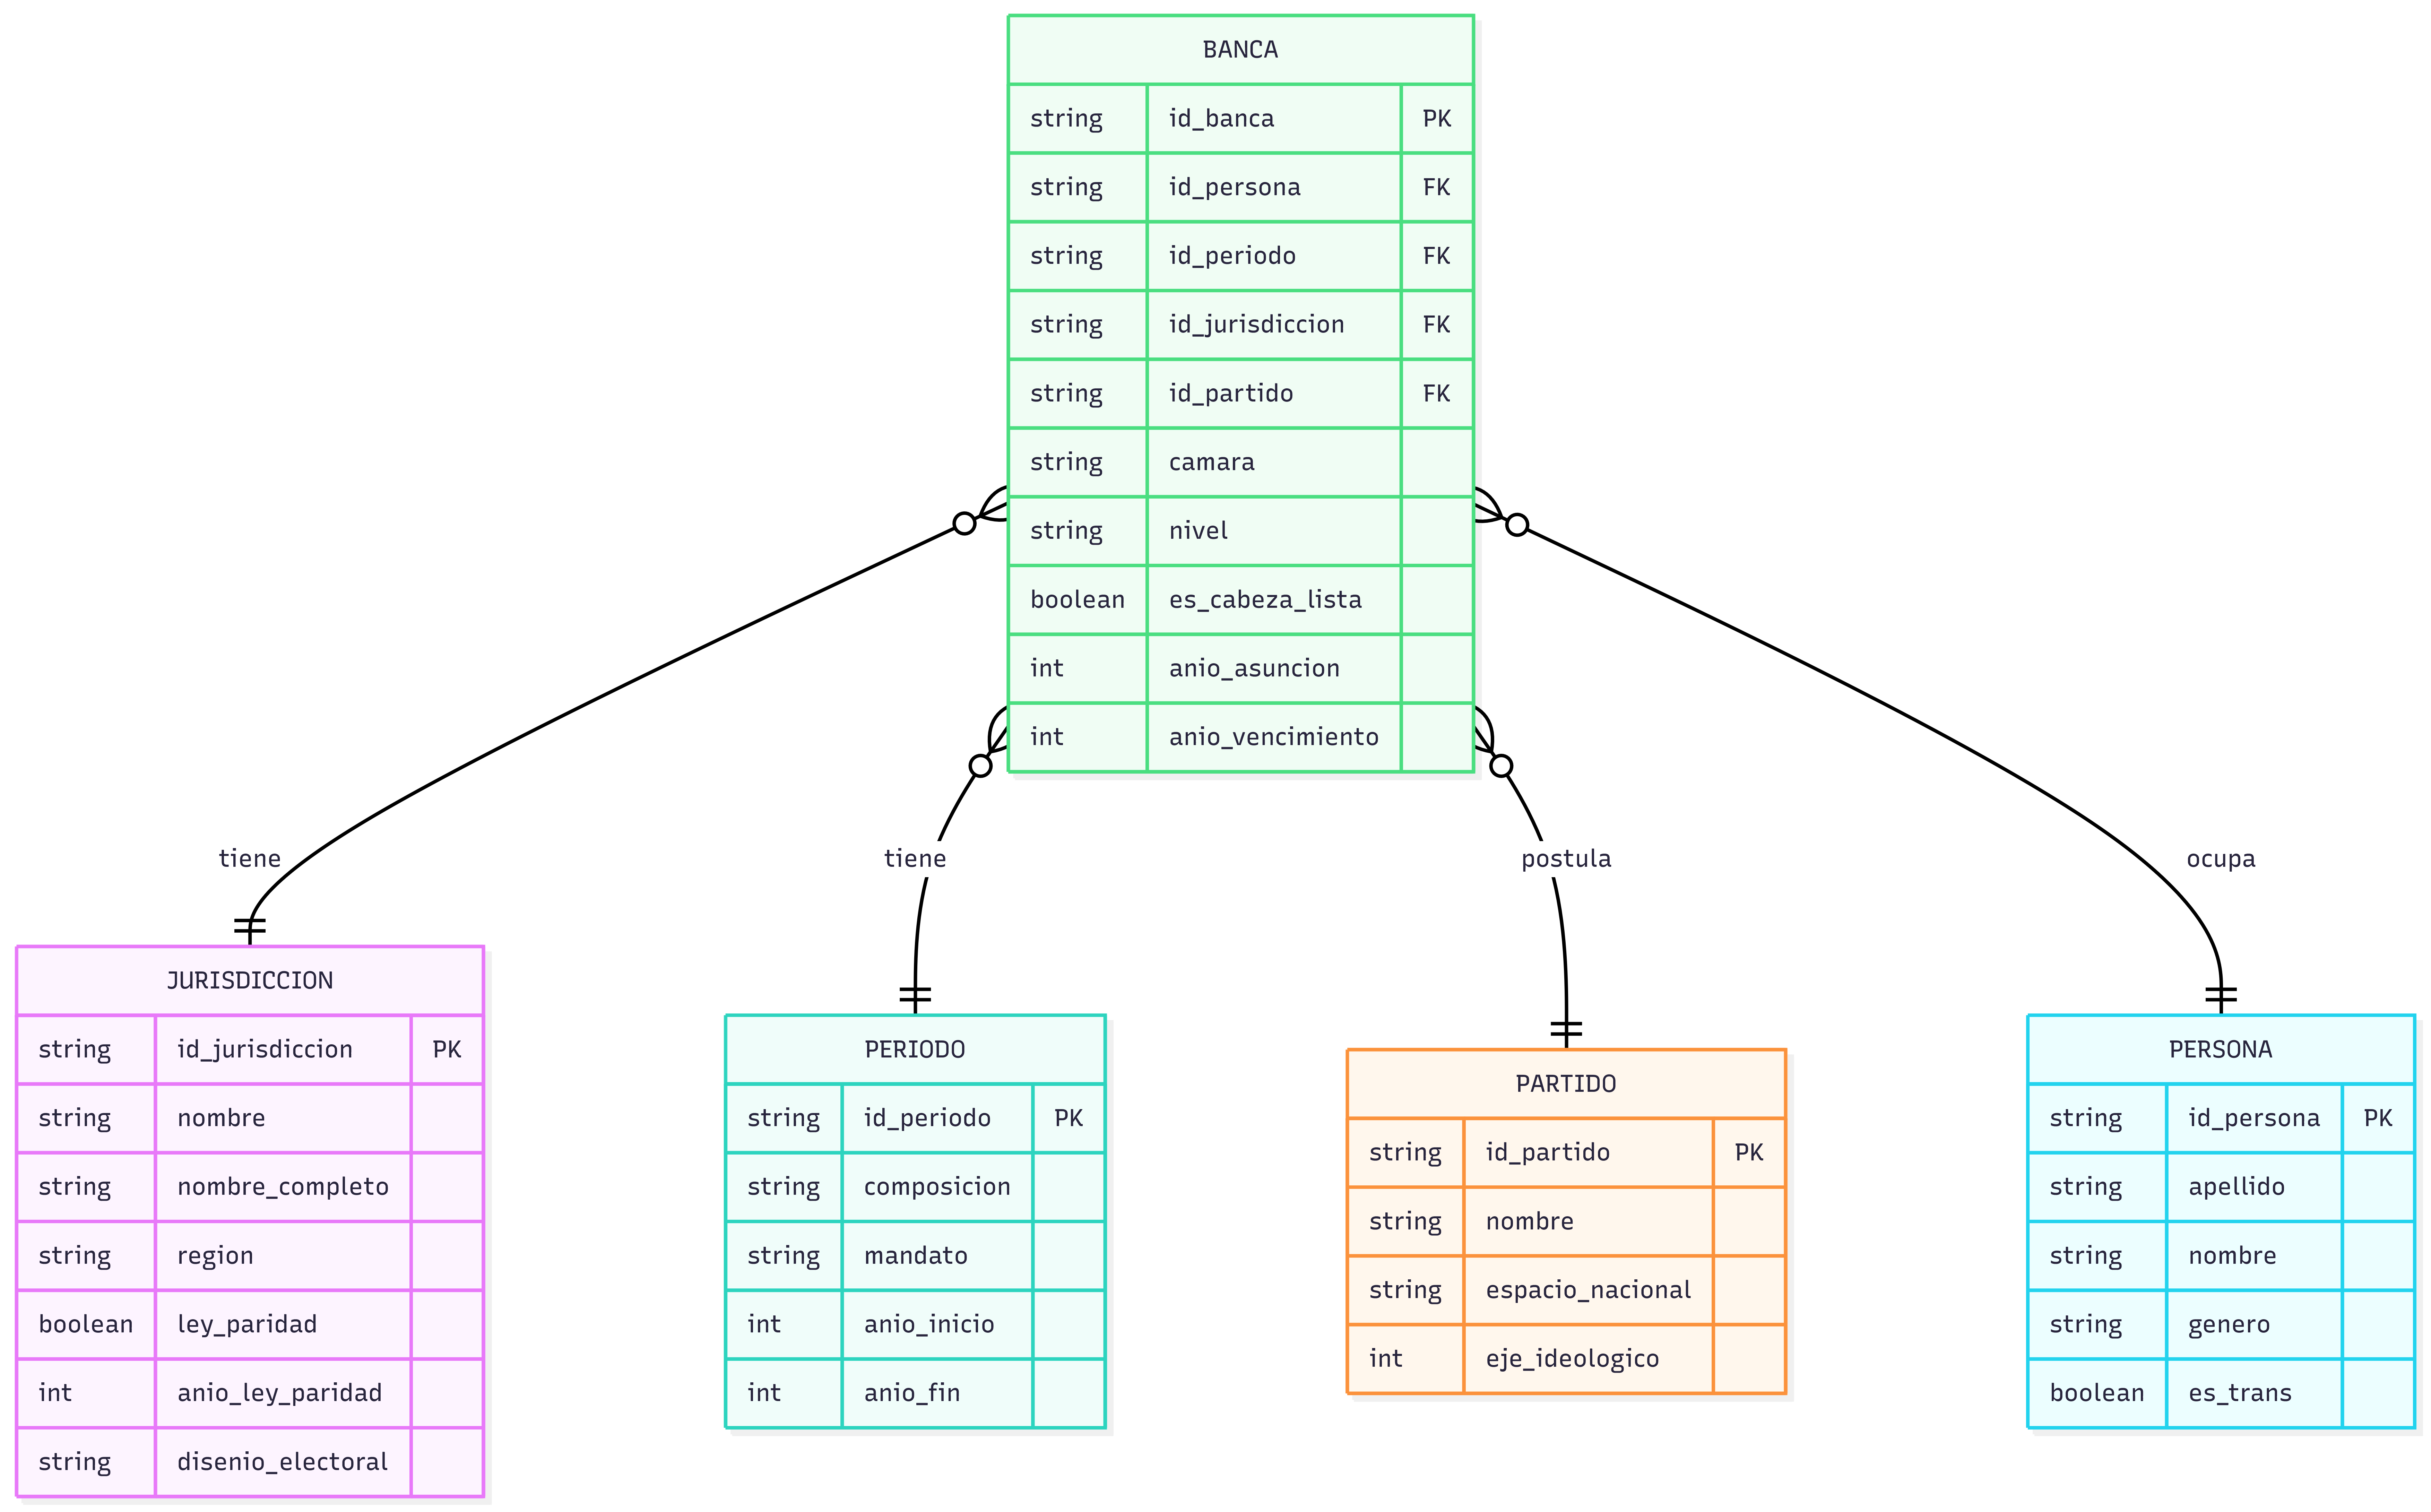

In [18]:
display(Image(filename=r'C:\Users\Asus\Documents\IT\Especialidad_IT_Academy\Proyecto\Visualizaciones\Modelo_final.png'))

In [19]:
# Lista de tablas a exportar como csv
tablas = ['jurisdiccion', 'periodo', 'partido', 'persona', 'banca']

# Exportar cada tabla a CSV
for tabla in tablas:
    # Leer la tabla
    df = pd.read_sql(f'SELECT * FROM {tabla}', engine)
    
    # Guardar como CSV
    df.to_csv(f'{tabla}.csv', index=False, encoding='utf-8-sig')
    print(f'Tabla "{tabla}" exportada a {tabla}.csv ({len(df)} registros)')

print("\n¡Exportación completada!")

Tabla "jurisdiccion" exportada a jurisdiccion.csv (24 registros)
Tabla "periodo" exportada a periodo.csv (8 registros)
Tabla "partido" exportada a partido.csv (624 registros)
Tabla "persona" exportada a persona.csv (8160 registros)
Tabla "banca" exportada a banca.csv (2302 registros)

¡Exportación completada!


In [21]:
# Guardar cada tabla en un DataFrame

# Tabla jurisdiccion
df_jurisdiccion = pd.read_sql("SELECT * FROM jurisdiccion", engine)

# Tabla periodo
df_periodo = pd.read_sql("SELECT * FROM periodo", engine)

# Tabla partido
df_partido = pd.read_sql("SELECT * FROM partido", engine)

# Tabla persona
df_persona = pd.read_sql("SELECT * FROM persona", engine)

# Tabla banca
df_banca = pd.read_sql("SELECT * FROM banca", engine)

# Verificar que se cargaron correctamente
print(f"jurisdiccion: {len(df_jurisdiccion)} registros")
print(f"periodo: {len(df_periodo)} registros")
print(f"partido: {len(df_partido)} registros")
print(f"persona: {len(df_persona)} registros")
print(f"banca: {len(df_banca)} registros")

jurisdiccion: 24 registros
periodo: 8 registros
partido: 624 registros
persona: 8160 registros
banca: 2302 registros
